# The Impact of Stigmatised Deprivation on Loneliness
Psycology Communications <br>
Author: Gregor Milligan <br> Date: 13th November 2024

This Notebook does the following:

1.0 Installs and imports appropriate python libraries

2.0 Importing the survey data analysed in the paper

3.0 Defining custom helper functions<br>
    <tab>3.1 Create the custom test train splits<br>
    <tab>3.2 A function to output the model results table<br>

4.0 Defining a custom function to train and test the random forest models to understand the impact of **stigmatised deprivation** on **loneliness**<br>
    4.1 Running the Base Random forest Model <br>
    4.2 Running Random Forest Model A <br>
    4.3 Running Random Forest Model B<br>
    4.4 Running Random Forest Model C

5.0 Performing statistical tests to identify the significance between the models<br>
    5.1 Friedman Chi Square Test<br>
    5.2 Wilcoxon signed-rank test

6.0 Performing MCR and SHAP Calculations and Visualising Model Results to show feature importance of each model



# 1.0 Pip installing Packages

In [1]:
!pip install numpy==1.22.4 Cython==0.29.25 pandas==1.3.5 matplotlib==3.5.1 seaborn==0.11.2

  Using cached numpy-1.21.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (2.1 kB)
  Using cached Cython-0.29.25-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached pandas-1.3.5.tar.gz (4.7 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached matplotlib-3.5.1-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.7 kB)
  Using cached seaborn-0.11.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.54.1-cp39-cp39-macosx_11_0_arm64.whl.metadata (163 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.0.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.0-py3-none-any.whl.metadata (5.0 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (60 kB)
INFO: pip is looking at multiple versions of scipy to determine which version

## 1.1 Importing the MCR Library directly from github

In [5]:
!pip install git+https://github.com/gavin-s-smith/mcrforest

  Cloning https://github.com/gavin-s-smith/mcrforest to /private/var/folders/1_/km5843sn2ws46n17k8mh6x6r0000gn/T/pip-req-build-uypxqy2t
  Running command git clone --filter=blob:none --quiet https://github.com/gavin-s-smith/mcrforest /private/var/folders/1_/km5843sn2ws46n17k8mh6x6r0000gn/T/pip-req-build-uypxqy2t
  Resolved https://github.com/gavin-s-smith/mcrforest to commit 685809d53972fe4f855777c4be13f3f6838b364f
  Preparing metadata (setup.py) ... done
  Created wheel for mcrforest: filename=mcrforest-3.1.0-cp39-cp39-macosx_11_0_arm64.whl size=1442232 sha256=36b1a8d91d91b774688d1abfe67345a711b48b4ff6482d73fd82daa7d9edd872
  Stored in directory: /private/var/folders/1_/km5843sn2ws46n17k8mh6x6r0000gn/T/pip-ephem-wheel-cache-ytjj1gzn/wheels/1a/91/af/aff14bc425034e3d8b06781478d2ee7d35bdb3c7daa7c6dabc
Successfully built mcrforest
Note: you may need to restart the kernel to use updated packages.


## 1.2 Importing Libraries/Packages

In [1]:
from sklearn.model_selection import train_test_split, GridSearchCV # Version 1.5.2
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np # Version 1.22.4
import pandas as pd # Version 1.3.5
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt # Version 3.5.1
plt.style.use('default')
from mcrforest.forest import RandomForestClassifier as mcr_rf # version 3.1.0  


# 2.0 Importing Data

In [4]:
#importing the dataset
model_df = pd.read_csv() # add stigmatised_deprivations_and_loneliness.csv here

model_df_all_covs_df = model_df.loc[:, [
    # --- Demographic Features ---
    'Age',
    'Income',
    'Unemployed',
    'Not Working (Looking After Child or House)',
    'Not Working Sick or Disabled',
    'Living On my Own With Children Under 18',
    'Gender',
    # --- Health and Wellbeing Features ---
    'Illness',
    # --- Financial Insecurity Features ---
    'Uses Foodbank',
    'Worry About Housing Payment',
    'Worry About Energy Payment',
    'Food Insecurity',
    'Energy Insecurity',

    
    # --- Social Support Features ---
    'Unable to Turn to Friends or Family',
    
    # --- MSOA/LSOA IMD Derived Features ---
    'IMD Score',
    'Living Environment Score',
    'Population Density',
    
    # --- Geographic and Infrastructure Features ---
    'Distance to Bus Stop',
    'Distance to Underground Access',
    'Distance to Railway Access',
    'Distance to Greenspace',
    
    # --- Loneliness Indicator ---
    'new_loneliness_binary'
]]
model_df_no_food_insecurity = model_df.loc[:, [
    # --- Demographic Features ---
    'Age',
    'Income',
    #'updated_income',
    'Unemployed',
    'Not Working (Looking After Child or House)',
    'Not Working Sick or Disabled',
    'Living On my Own With Children Under 18',
    'Gender',
    # --- Health and Wellbeing Features ---
    'Illness',
    # --- Financial Insecurity Features ---
    'Uses Foodbank',
    'Worry About Housing Payment',
    'Worry About Energy Payment',
    #'Food Insecurity',
    'Energy Insecurity',
 
    # --- Social Support Features ---
    'Unable to Turn to Friends or Family',
    
    # --- MSOA/LSOA IMD Derived Features ---
    'IMD Score',
    'Living Environment Score',
    'Population Density',
    
    # --- Geographic and Infrastructure Features ---
    'Distance to Bus Stop',
    'Distance to Underground Access',
    'Distance to Railway Access',
    'Distance to Greenspace',
    
    # --- Loneliness Indicator ---
    'new_loneliness_binary'
]]
model_df_no_energy_insecurity = model_df.loc[:, [
    # --- Demographic Features ---
    'Age',
    'Income',
    'Unemployed',
    'Not Working (Looking After Child or House)',
    'Not Working Sick or Disabled',
    'Living On my Own With Children Under 18',
    'Gender',
    # --- Health and Wellbeing Features ---
    'Illness',
    # --- Financial Insecurity Features ---
    'Uses Foodbank',
    'Worry About Housing Payment',
    'Worry About Energy Payment',
    'Food Insecurity',
    #'Energy Insecurity',

    
    # --- Social Support Features ---
    'Unable to Turn to Friends or Family',
    # --- MSOA/LSOA IMD Derived Features ---
    'IMD Score',
    'Living Environment Score',
    'Population Density',
    
    # --- Geographic and Infrastructure Features ---
    'Distance to Bus Stop',
    'Distance to Underground Access',
    'Distance to Railway Access',
    'Distance to Greenspace',
    
    # --- Loneliness Indicator ---
    'new_loneliness_binary'
]]
model_df_no_food_or_energy_insecurity = model_df.loc[:, [
    # --- Demographic Features ---
    'Age',
    'Income',
    'Unemployed',
    'Not Working (Looking After Child or House)',
    'Not Working Sick or Disabled',
    'Living On my Own With Children Under 18',
    'Gender',
    # --- Health and Wellbeing Features ---
    'Illness',
    # --- Financial Insecurity Features ---
    'Uses Foodbank',
    'Worry About Housing Payment',
    'Worry About Energy Payment',
    #'Food Insecurity',
    #'Energy Insecurity',
    
    # --- Social Support Features ---
    'Unable to Turn to Friends or Family',
    
    # --- MSOA/LSOA IMD Derived Features ---
    'IMD Score',
    'Living Environment Score',
    'Population Density',
    
    # --- Geographic and Infrastructure Features ---
    'Distance to Bus Stop',
    'Distance to Underground Access',
    'Distance to Railway Access',
    'Distance to Greenspace',
    
    # --- Loneliness Indicator ---
    'new_loneliness_binary'
]]

# 3.0 Helper Functions

## 3.1 Creating Custom Test Train Splits

In [4]:
# Split the data into training and testing sets
random_states=[40,41,42,43,44]
def create_test_train_sets(random_state, dataset_to_split, test_size=0.30, sample_size=500, target_feature='new_loneliness_binary'):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    sets= []
        # Sample 500 observations where new_loneliness_binary is 1
    df_lonely = dataset_to_split[dataset_to_split['new_loneliness_binary'] == 1].sample(n=sample_size, random_state=41)
    # Sample 500 observations where new_loneliness_binary is 0
    df_not_lonely = dataset_to_split[dataset_to_split['new_loneliness_binary'] == 0].sample(n=sample_size, random_state=41)
    # Concatenate the two samples to create model_df
    model_df = pd.concat([df_lonely, df_not_lonely], axis=0).reset_index(drop=True)

    # removes all of the features in the list of features to remove to understand the impact of removing all of the features from the model
    df_copy = model_df.copy()
    X = df_copy.drop(columns=[target_feature])
    y = df_copy[target_feature]

    for i in random_state:

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i, stratify=y)

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
        X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
        number_of_lonely_in_test = y_test.sum()
        sets.append({
            'X_train': X_train_scaled_df,
            'X_test': X_test_scaled_df,
            'y_train': y_train,
            'y_test': y_test,
            'test_size': test_size,
            'number_of_lonely_in_test': number_of_lonely_in_test
        })

    return sets
# Create the test and train sets for the models
train_test_sets = create_test_train_sets(random_state=random_states, dataset_to_split=model_df_all_covs_df, sample_size=500, target_feature='new_loneliness_binary')
excluding_food_train_test_sets = create_test_train_sets(random_state=random_states, dataset_to_split=model_df_no_food_insecurity, sample_size=500, target_feature='new_loneliness_binary')
excluding_energy_train_test_sets = create_test_train_sets(random_state=random_states, dataset_to_split=model_df_no_energy_insecurity, sample_size=500, target_feature='new_loneliness_binary')
excluding_food_and_energy_train_test_sets = create_test_train_sets(random_state=random_states, dataset_to_split=model_df_no_food_or_energy_insecurity, sample_size=500, target_feature='new_loneliness_binary')

## 3.2 Extracting Restuls From Random Forests and Producing Table of Results

In [ ]:
def extract_pattern(input_list, start=0, step=4, group_size=4):
    """
    Extracts a pattern from the input list based on the specified start, step, and group size.

    Parameters:
    input_list (list): The list from which to extract the pattern.
    start (int): The starting index for extraction.
    step (int): The step size for extraction.
    group_size (int): The size of each group to extract.

    Returns:
    list: A list containing the extracted pattern.
    """
    result = []
    for i in range(start, len(input_list), step):
        if i + group_size <= len(input_list):
            result.extend(input_list[i:i+group_size])
    return result

def create_rf_results_df(model_results_list):
    """
    Creates a DataFrame from the model results list.

    Parameters:
    model_results_list (list): The list containing model results.

    Returns:
    DataFrame: A pandas DataFrame containing the model results.
    """
    columns = ['Random State', 'Model Accuracy', 'Cross Validation Accuracy', 'Optimal Parameters', 'True Positives', 'False Negatives', 'False Positives', 'True Negatives']
    extracted_elements = extract_pattern(model_results_list)
    rf_result_df = pd.DataFrame([extracted_elements[i:i+8] for i in range(0, len(extracted_elements), 8)], columns=columns)
    return rf_result_df

def dispay_df(df, name, accuracy_column='Model Accuracy', cross_val_column='Cross Validation Accuracy'):
    """
    Displays the DataFrame and prints the average model accuracy and cross-validation accuracy.

    Parameters:
    df (DataFrame): The DataFrame to display.
    name (str): The name of the DataFrame.
    accuracy_column (str): The column name for model accuracy.
    cross_val_column (str): The column name for cross-validation accuracy.
    """
    print(f"\n--- {name} ---")
    print(f"Average Model Accuracy: {df[accuracy_column].mean():.4f}")
    print("\n")
    print(f"Average Cross Validation Accuracy: {df[cross_val_column].mean():.4f}")
    display(df)

# 4.0 Random Forest Models

In [7]:
# Defining a function to loop through the random states and datasets to find the best parameters for the Random Forest Classifier
def rf_classifier_loop(custom_test_train_sets, random_state=random_states):
    from sklearn.ensemble import RandomForestClassifier
    param_grid = {
        'n_estimators': [500],
        'max_depth': [5, 10, 15, 20],
        'criterion': ['gini', 'entropy'],
        'min_samples_split': [2, 3, 5, 7, 10],
    }

    for random_state in random_states:
        for i, dataset in enumerate(custom_test_train_sets): 
            
            rf_clf = RandomForestClassifier(random_state=random_state, bootstrap=False)

    # Instantiate the grid search model
            grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, 
                                    cv=5, n_jobs=-1, verbose=0, scoring='accuracy')

            # Fit the grid search to the data
            grid_search.fit(dataset['X_train'], dataset['y_train'])

            # Print the best parameters
            #print("Best parameters found: ", grid_search.best_params_)

            # Get the best model
            best_rf = grid_search.best_estimator_
            cross_validation_accuracy = grid_search.best_score_
            # Make predictions using the best model
            y_pred = best_rf.predict(dataset['X_test'])
            
            
            #print(f"-------Dataset{i}-------")
            #print(f"Random State: {random_state}")
            a_score = accuracy_score(dataset['y_test'], y_pred)
            
            #print("accuracy score ---- ", accuracy_score(dataset['y_test'], y_pred))

            conf_matrix = confusion_matrix(dataset['y_test'], y_pred)
            #print("Confusion Matrix:\n", conf_matrix)

            # Extract TP, FN, FP and TN from confusion matrix
            TP = conf_matrix[1, 1]
            FN = conf_matrix[1, 0]
            FP = conf_matrix[0, 1]
            TN = conf_matrix[0, 0]
            print("\n") 

            yield a_score, random_state, dataset, best_rf, cross_validation_accuracy, TP, FN,  FP, TN

In [8]:
## Executing the rf_classifier_loop function and yielding the values to rf_scores_list
rf_scores_list_all_covariates = []
for i, (a_score, random_state, dataset, best_rf, cross_validation_accuracy, TP, FN, FP, TN) in enumerate(rf_classifier_loop(custom_test_train_sets=train_test_sets)):
    rf_scores_list_all_covariates.extend([
        random_state,
        a_score,
        cross_validation_accuracy,
        best_rf,
        TP,
        FN,
        FP,
        TN
    ])

## 4.1 Extracting the values from the results list into a results dataframe 

In [88]:
rf_results_all_covariates_df = create_rf_results_df(rf_scores_list_all_covariates)
dispay_df(rf_results_all_covariates_df, "All Covariates")


--- All Covariates ---
Average Model Accuracy: 0.6960


Average Cross Validation Accuracy: 0.7024


,Random State,Model Accuracy,Cross Validation Accuracy,Optimal Parameters,True Positives,False Negatives,False Positives,True Negatives
0,40,0.696667,0.707143,"(DecisionTreeClassifier(max_depth=5, max_featu...",100,50,41,109
1,40,0.723333,0.684286,"(DecisionTreeClassifier(max_depth=5, max_featu...",106,44,39,111
2,40,0.686667,0.697143,"(DecisionTreeClassifier(max_depth=5, max_featu...",92,58,36,114
3,40,0.673333,0.714286,"(DecisionTreeClassifier(max_depth=5, max_featu...",104,46,52,98
4,40,0.683333,0.701429,"(DecisionTreeClassifier(max_depth=10, max_feat...",99,51,44,106
5,41,0.700000,0.708571,"(DecisionTreeClassifier(max_depth=5, max_featu...",100,50,40,110
6,41,0.736667,0.690000,"(DecisionTreeClassifier(max_depth=5, max_featu...",107,43,36,114
7,41,0.680000,0.700000,"(DecisionTreeClassifier(max_depth=5, max_featu...",90,60,36,114
8,41,0.683333,0.714286,"(DecisionTreeClassifier(max_depth=5, max_featu...",106,44,51,99
9,41,0.693333,0.695714,"(DecisionTreeClassifier(criterion='entropy', m...",100,50,42,108


In [25]:
rf_results_all_covariates_df.to_clipboard()

## 4.2 Random Forests Excluding Foof Insecurity

In [10]:
rf_scores_list_excluding_FI = []
for i, (a_score, random_state, dataset, best_rf, cross_validation_accuracy, TP, FN, FP, TN) in enumerate(rf_classifier_loop(custom_test_train_sets=excluding_food_train_test_sets)):
    rf_scores_list_excluding_FI.extend([
        random_state,
        a_score,
        cross_validation_accuracy,
        best_rf,
        TP,
        FN,
        FP,
        TN
    ])

In [17]:
rf_results_excluding_FI = create_rf_results_df(rf_scores_list_excluding_FI)
dispay_df(rf_results_excluding_FI, "Excluding FI")


--- Excluding FI ---
Average Model Accuracy: 0.68


Average Cross Validation Accuracy: 0.70


,Random State,Model Accuracy,Cross Validation Accuracy,Optimal Parameters,True Positives,False Negatives,False Positives,True Negatives
0,40,0.686667,0.707143,"(DecisionTreeClassifier(max_depth=20, max_feat...",98,52,42,108
1,40,0.713333,0.694286,"(DecisionTreeClassifier(criterion='entropy', m...",112,38,48,102
2,40,0.660000,0.680000,"(DecisionTreeClassifier(max_depth=5, max_featu...",93,57,45,105
3,40,0.676667,0.712857,"(DecisionTreeClassifier(max_depth=5, max_featu...",106,44,53,97
4,40,0.673333,0.698571,"(DecisionTreeClassifier(max_depth=5, max_featu...",109,41,57,93
5,41,0.693333,0.701429,"(DecisionTreeClassifier(criterion='entropy', m...",99,51,41,109
6,41,0.706667,0.688571,"(DecisionTreeClassifier(criterion='entropy', m...",110,40,48,102
7,41,0.663333,0.675714,"(DecisionTreeClassifier(criterion='entropy', m...",95,55,46,104
8,41,0.673333,0.712857,"(DecisionTreeClassifier(max_depth=5, max_featu...",106,44,54,96
9,41,0.680000,0.692857,"(DecisionTreeClassifier(criterion='entropy', m...",108,42,54,96


In [26]:
rf_results_excluding_FI.to_clipboard()

## 4.3 Random Forests Excluding Energy Insecurity

In [12]:
rf_scores_list_excluding_EI = []
for i, (a_score, random_state, dataset, best_rf, cross_validation_accuracy, TP, FN, FP, TN) in enumerate(rf_classifier_loop(custom_test_train_sets=excluding_energy_train_test_sets)):
    rf_scores_list_excluding_EI.extend([
        random_state,
        a_score,
        cross_validation_accuracy,
        best_rf,
        TP,
        FN,
        FP,
        TN
    ])

In [18]:
rf_results_excluding_EI = create_rf_results_df(rf_scores_list_excluding_EI)
dispay_df(rf_results_excluding_EI, "Excluding EI")


--- Excluding EI ---
Average Model Accuracy: 0.69


Average Cross Validation Accuracy: 0.71


,Random State,Model Accuracy,Cross Validation Accuracy,Optimal Parameters,True Positives,False Negatives,False Positives,True Negatives
0,40,0.696667,0.712857,"(DecisionTreeClassifier(criterion='entropy', m...",100,50,41,109
1,40,0.700000,0.687143,"(DecisionTreeClassifier(max_depth=5, max_featu...",100,50,40,110
2,40,0.690000,0.701429,"(DecisionTreeClassifier(max_depth=5, max_featu...",95,55,38,112
3,40,0.670000,0.714286,"(DecisionTreeClassifier(max_depth=5, max_featu...",104,46,53,97
4,40,0.696667,0.710000,"(DecisionTreeClassifier(criterion='entropy', m...",101,49,42,108
5,41,0.696667,0.717143,"(DecisionTreeClassifier(criterion='entropy', m...",101,49,42,108
6,41,0.720000,0.690000,"(DecisionTreeClassifier(max_depth=5, max_featu...",103,47,37,113
7,41,0.693333,0.708571,"(DecisionTreeClassifier(max_depth=5, max_featu...",94,56,36,114
8,41,0.670000,0.720000,"(DecisionTreeClassifier(max_depth=5, max_featu...",104,46,53,97
9,41,0.696667,0.710000,"(DecisionTreeClassifier(max_depth=5, max_featu...",100,50,41,109


In [27]:
rf_results_excluding_EI.to_clipboard()

## 4.4 Random Forests Excluding Both Energy and Food Insecurity

In [14]:
rf_scores_list_excluding_FI_and_EI = []
for i, (a_score, random_state, dataset, best_rf, cross_validation_accuracy, TP, FN, FP, TN) in enumerate(rf_classifier_loop(custom_test_train_sets=excluding_food_and_energy_train_test_sets)):
    rf_scores_list_excluding_FI_and_EI.extend([
        random_state,
        a_score,
        cross_validation_accuracy,
        best_rf,
        TP,
        FN,
        FP,
        TN
    ])

In [19]:
rf_results_excluding_FI_and_EI = create_rf_results_df(rf_scores_list_excluding_FI_and_EI)
dispay_df(rf_results_excluding_FI_and_EI, "Excluding EI and FI")


--- Excluding EI and FI ---
Average Model Accuracy: 0.68


Average Cross Validation Accuracy: 0.69


,Random State,Model Accuracy,Cross Validation Accuracy,Optimal Parameters,True Positives,False Negatives,False Positives,True Negatives
0,40,0.686667,0.704286,"(DecisionTreeClassifier(criterion='entropy', m...",98,52,42,108
1,40,0.693333,0.690000,"(DecisionTreeClassifier(max_depth=5, max_featu...",107,43,49,101
2,40,0.666667,0.684286,"(DecisionTreeClassifier(max_depth=5, max_featu...",100,50,50,100
3,40,0.670000,0.697143,"(DecisionTreeClassifier(criterion='entropy', m...",108,42,57,93
4,40,0.670000,0.695714,"(DecisionTreeClassifier(criterion='entropy', m...",106,44,55,95
5,41,0.683333,0.702857,"(DecisionTreeClassifier(criterion='entropy', m...",106,44,51,99
6,41,0.693333,0.687143,"(DecisionTreeClassifier(max_depth=5, max_featu...",107,43,49,101
7,41,0.673333,0.685714,"(DecisionTreeClassifier(max_depth=5, max_featu...",100,50,48,102
8,41,0.676667,0.694286,"(DecisionTreeClassifier(criterion='entropy', m...",110,40,57,93
9,41,0.660000,0.695714,"(DecisionTreeClassifier(criterion='entropy', m...",104,46,56,94


## 4.5 Getting Avarage Model Parametes  Values From the Model Results Table

In [20]:
def extract_and_mode_rf_params(df_column):
    """
    Extract all parameter values and find modes from RandomForestClassifier strings in DataFrame column
    
    Parameters:
    df_column (pandas.Series): DataFrame column containing RandomForestClassifier strings
    
    Returns:
    tuple: (parameter counts dict, parameter modes dict)
    """
    from collections import Counter
    
    # Initialize counters for each parameter
    param_counts = {
        'bootstrap': Counter(),
        'criterion': Counter(),
        'max_depth': Counter(),
        'min_samples_split': Counter(),
        'n_estimators': Counter(),
        'random_state': Counter()
    }
    
    for rf_string in df_column:
        # Convert to string and clean up
        rf_string = str(rf_string)
        params_str = rf_string.strip('"').replace('\n', ' ')
        params_str = params_str.replace('RandomForestClassifier(', '').rstrip(')')
        params = params_str.split(', ')
        
        # Track parameters found in this configuration
        found_params = set()
        
        # Extract and count parameter values
        for param in params:
            name, value = param.split('=')
            # Strip whitespace from parameter name
            name = name.strip()
            found_params.add(name)
            
            # Convert value to appropriate type
            if value.lower() == 'false':
                value = False
            elif value.lower() == 'true':
                value = True
            elif value.isdigit():
                value = int(value)
            elif value.startswith("'") and value.endswith("'"):
                value = value.strip("'")
            
            # Strip any whitespace from the value if it's a string
            if isinstance(value, str):
                value = value.strip()
                
            param_counts[name][value] += 1
        
        # Add default values for any missing parameters
        for param in param_counts:
            if param not in found_params:
                if param == 'criterion':
                    param_counts[param]['gini (default)'] += 1
    
    # Find mode (most common value) for each parameter
    param_modes = {}
    for param, counts in param_counts.items():
        if counts:  # if there are any values
            mode_value = counts.most_common(1)[0][0]  # get the most common value
            mode_count = counts.most_common(1)[0][1]  # get its count
            total = sum(counts.values())
            mode_percentage = (mode_count / total) * 100
            param_modes[param] = (mode_value, mode_percentage)
    
    return param_counts, param_modes

def print_results(param_modes):
    print("\nMode values for the Base Model:")
    for param, (mode_value, percentage) in param_modes.items():
        print(f"{param}: {mode_value} ({percentage:.1f}%)")

# Usage:
param_counts, param_modes = extract_and_mode_rf_params(rf_results_all_covariates_df['Optimal Parameters'])
print_results(param_modes)


Mode values for the Base Model:
bootstrap: False (100.0%)
criterion: gini (default) (84.0%)
max_depth: 5 (92.0%)
min_samples_split: 10 (33.3%)
n_estimators: 500 (100.0%)
random_state: 40 (20.0%)


In [21]:
param_counts, param_modes = extract_and_mode_rf_params(rf_results_excluding_FI['Optimal Parameters'])
print_results(param_modes)


Mode values for the Base Model:
bootstrap: False (100.0%)
criterion: gini (default) (60.0%)
max_depth: 5 (80.0%)
min_samples_split: 7 (38.1%)
n_estimators: 500 (100.0%)
random_state: 40 (20.0%)


In [22]:
param_counts, param_modes = extract_and_mode_rf_params(rf_results_excluding_EI['Optimal Parameters'])
print_results(param_modes)


Mode values for the Base Model:
bootstrap: False (100.0%)
criterion: gini (default) (60.0%)
max_depth: 5 (100.0%)
min_samples_split: 5 (30.0%)
n_estimators: 500 (100.0%)
random_state: 40 (20.0%)


In [19]:
param_counts, param_modes = extract_and_mode_rf_params(rf_results_excluding_FI_and_EI['Optimal Parameters'])
print_results(param_modes)


Mode values for the Base Model:
bootstrap: False (100.0%)
criterion: gini (default) (56.0%)
max_depth: 5 (96.0%)
min_samples_split: 5 (33.3%)
n_estimators: 500 (100.0%)
random_state: 40 (20.0%)


# 5.0 Statistical Tests 
To understand the significance between the models

## 5.1 Friedman Chi Square Test

In [82]:
# Importing the results dataset (transformed from the original dataset to enable statistical testing)
statistical_test_df = pd.read_csv('LOLO_Results_Statistical_Testing.csv')
statistical_test_df.head(3)

,RandomState,BaseModel,ModelA,ModelB,ModelC
0,40,0.6967,0.6867,0.6967,0.6867
1,40,0.7233,0.7133,0.7000,0.6933
2,40,0.6867,0.6640,0.6940,0.6667
3,40,0.6733,0.6767,0.6740,0.6740
4,40,0.6833,0.6733,0.6967,0.6740
5,41,0.7400,0.6933,0.6967,0.6833
6,41,0.7367,0.7067,0.7240,0.6933
7,41,0.6840,0.6633,0.6933,0.6733
8,41,0.6833,0.6733,0.6740,0.6767
9,41,0.6933,0.6840,0.6967,0.6640


In [83]:
from scipy.stats import friedmanchisquare

# Assuming your data is in arrays representing accuracies for each model per random state
statistic, p_value = friedmanchisquare(statistical_test_df['BaseModel'], statistical_test_df['ModelA'], statistical_test_df["ModelB"])
# Run the Friedman test

# Print the results
print("Friedman Test Statistic:", statistic)
print("P-value:", p_value)

Friedman Test Statistic: 12.966292134831484
P-value: 0.001528992790200167


## 5.2 Wilcoxon signed-rank test 
To understand the statistical difference across the models

In [85]:
from scipy.stats import wilcoxon

# Pairwise comparisons (adjusted significance level for Bonferroni correction)
alpha = 0.05
adjusted_alpha = alpha / 6  # Bonferroni correction for six comparisons

# Define model accuracies as lists (these should already be defined)
# base_model, model_a, model_b, model_c

# Perform pairwise Wilcoxon tests
results = {}
results["Base vs A"] = wilcoxon(statistical_test_df['BaseModel'], statistical_test_df['ModelA'])
results["Base vs B"] = wilcoxon(statistical_test_df['BaseModel'], statistical_test_df["ModelB"])
results["Base vs C"] = wilcoxon(statistical_test_df['BaseModel'], statistical_test_df["ModelC"])
results["A vs B"] = wilcoxon(statistical_test_df['ModelA'], statistical_test_df["ModelB"])
results["A vs C"] = wilcoxon(statistical_test_df['ModelA'], statistical_test_df["ModelC"])
results["B vs C"] = wilcoxon(statistical_test_df["ModelB"], statistical_test_df["ModelC"])

# Print results in a structured table format with Bonferroni-adjusted significance threshold
print("Pairwise Wilcoxon Test Results (with Bonferroni correction):")
print(f"{'Comparison':<15}{'Statistic':<15}{'P-value':<15}{'Significant':<15}")
print("="*60)

for comparison, (statistic, p_value) in results.items():
    significant = "Yes" if p_value < adjusted_alpha else "No"
    print(f"{comparison:<15}{statistic:<15.4f}{p_value:<15.4e}{significant:<15}")
    
print(f"\nNote: Comparisons are significant if p-value < {adjusted_alpha:.4f} (Bonferroni-adjusted).")
import pandas as pd

# Prepare data for the DataFrame
data = {
    "Comparison": [],
    "Statistic": [],
    "P-value": [],
    "Significant": []
}

# Populate data dictionary with Wilcoxon test results
for comparison, (statistic, p_value) in results.items():
    data["Comparison"].append(comparison)
    data["Statistic"].append(statistic)
    data["P-value"].append(p_value)
    data["Significant"].append("Yes" if p_value < adjusted_alpha else "No")

# Create DataFrame
Statistical_test_results_df = pd.DataFrame(data)
Statistical_test_results_df.to_clipboard()

Pairwise Wilcoxon Test Results (with Bonferroni correction):
Comparison     Statistic      P-value        Significant    
Base vs A      12.5000        1.2911e-04     Yes            
Base vs B      73.5000        2.3940e-01     No             
Base vs C      5.5000         8.3447e-07     Yes            
A vs B         40.0000        4.9578e-03     Yes            
A vs C         80.5000        7.9599e-02     No             
B vs C         3.5000         4.1901e-05     Yes            

Note: Comparisons are significant if p-value < 0.0083 (Bonferroni-adjusted).


# 6.0 MCR/SHAP Modelling and Visualisation

**Note:** For the following visualisations, some minor cosmetic alterations have been made to the _forest.py file within the mcrforest library. <br> This is to make the visualisations clearer for the reader of the paper and to ensure consistency of language throughout the paper.

Inside the ```plot_mcr()``` function, the y-axis label has been changed from *'variable'* to *'Feature'*, and the x-axis label has been changed from *'MCR- (lollipops) | MCR+ (bars)'* to *'Feature Importance Score \n MCR- (lollipops) | MCR+ (bars)'*.

In [ ]:
from mcrforest.forest import RandomForestClassifier as mcr_rf # version 3.1.0


## Base Model: All Covariates

Processing MCR+ groups of features.


100%|██████████| 21/21 [01:42<00:00,  4.86s/it]


Processing MCR- groups of features.


100%|██████████| 21/21 [01:39<00:00,  4.75s/it]


MCR+ sum: 0.5544153082919914


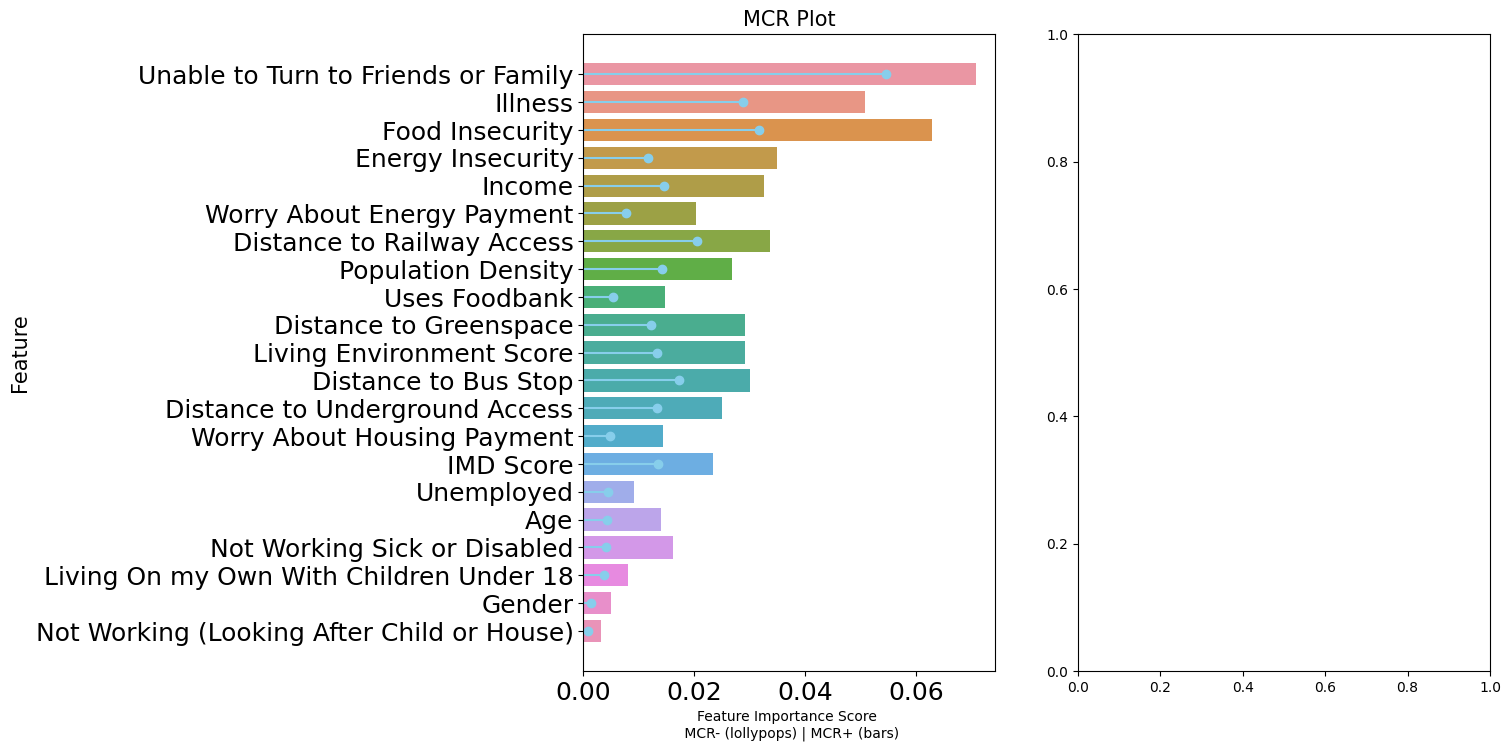

 set_estimators(self, force_use = False, var_indexs = [0], debug = True )


 99%|===================| 5593/5644 [01:19<00:00]        

 set_estimators(self, force_use = False, var_indexs = [1], debug = True )


100%|===================| 5631/5644 [01:21<00:00]        

 set_estimators(self, force_use = False, var_indexs = [2], debug = True )


...

 99%|===================| 5613/5644 [01:24<00:00]        

 set_estimators(self, force_use = False, var_indexs = [19], debug = True )


 99%|===================| 5592/5644 [01:22<00:00]        

 set_estimators(self, force_use = False, var_indexs = [20], debug = True )


 99%|===================| 5602/5644 [01:22<00:00]        

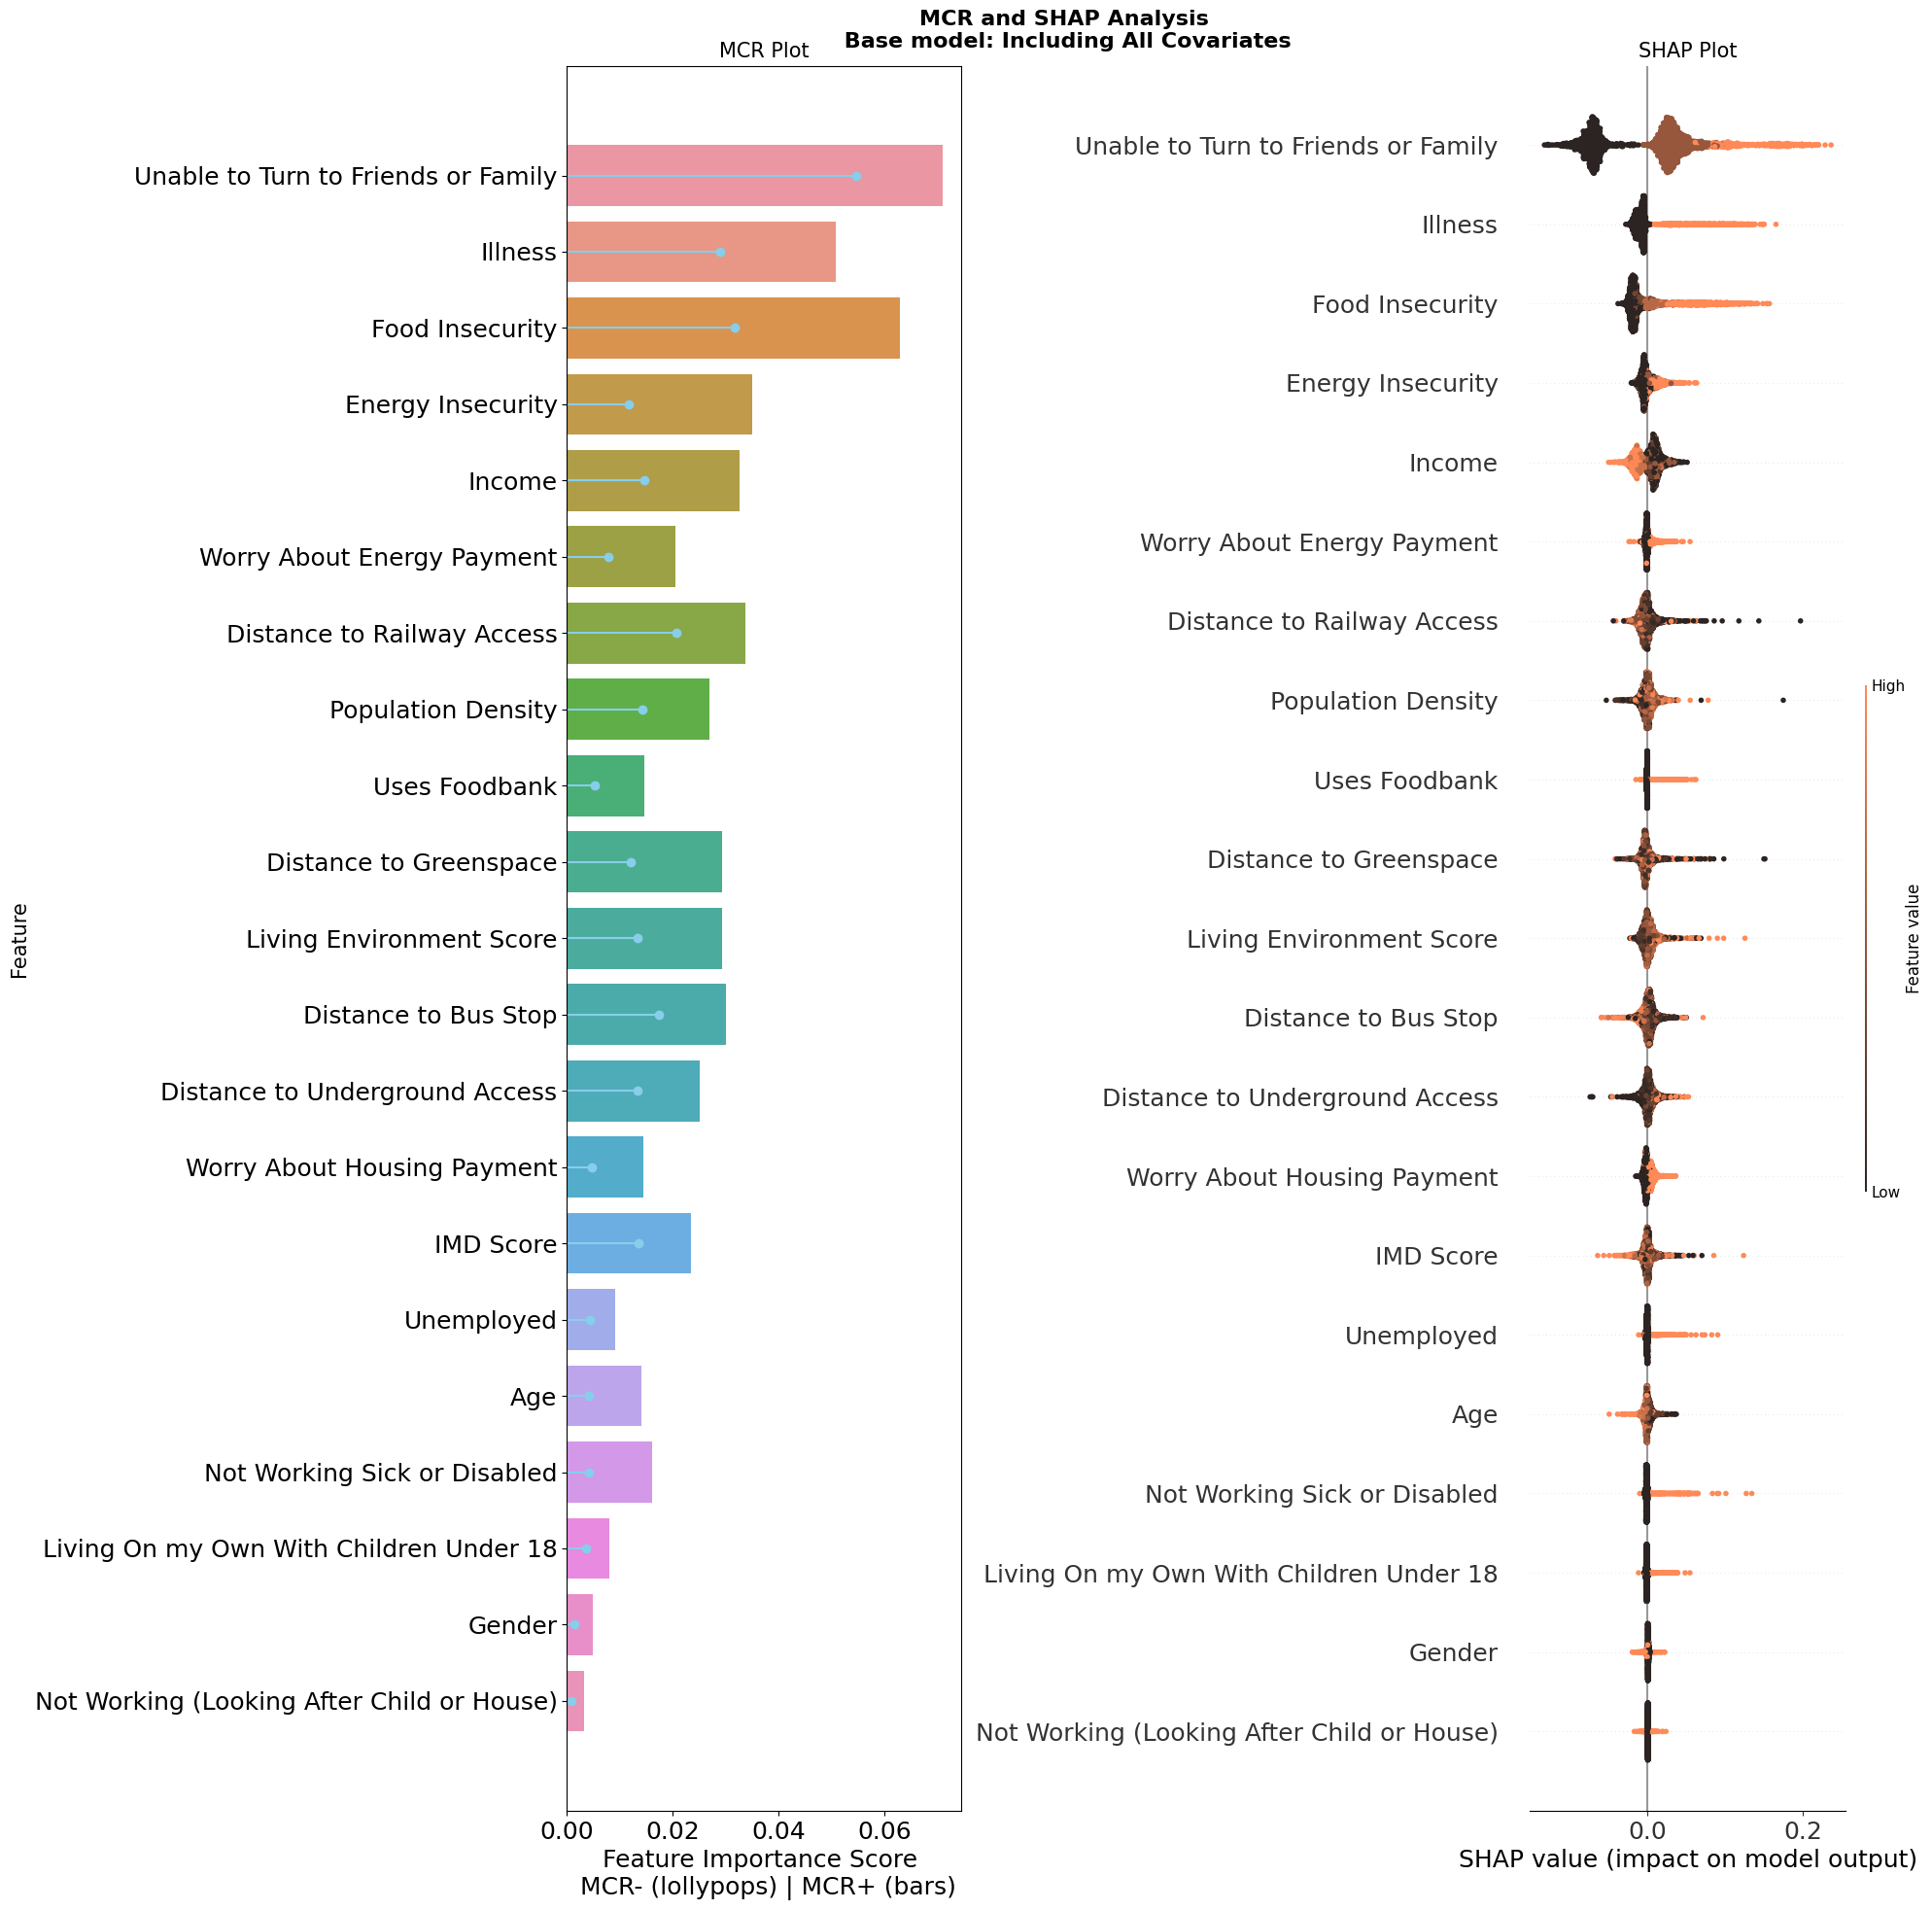

,Feature,MCR-,MCR+
0,Unable to Turn to Friends or Family,0.054614,0.070829
1,Illness,0.028845,0.050801
2,Food Insecurity,0.031736,0.062835
3,Energy Insecurity,0.011623,0.034926
4,Income,0.014628,0.032587
5,Worry About Energy Payment,0.007768,0.020425
6,Distance to Railway Access,0.020595,0.033607
7,Population Density,0.014245,0.026832
8,Uses Foodbank,0.005287,0.014670
9,Distance to Greenspace,0.012133,0.029270


In [ ]:
X = model_df_all_covs_df.drop(columns=['new_loneliness_binary'])
y = model_df_all_covs_df['new_loneliness_binary']
# Defining the MCR model 
mcr_model = mcr_rf(bootstrap=False, criterion='entropy', max_depth=5,
                       min_samples_split=7, n_estimators=500, random_state=42)
# Fit the MCR Random Forest estimator to the training data
mcr_model.fit(X, y.values.ravel())

fig, axs = plt.subplots(1, 2, figsize=(30, 30))  # Create a 1x2 grid of subplots
 # assigning the MCR plot to the first subplot
plt.sca(axs[0])
# plot title 
axs[0].set_title('MCR Plot', fontsize=15) 
axs[0].tick_params(labelsize=18)
axs[0].set_ylabel('Feature', fontsize=15)
mrc_rf_estimator_mcr_table= mcr_model.plot_mcr(X, y, num_times=25)
#mrc_rf_estimator_mcr_table= mcr_model.plot_mcr(X, y,num_times=10)
# calling the function that plots the MCR, ordred by MCR+ or MCR- column in the mrc_rf_estimator_mcr_table

# assigning the MCR SHAP plot to the first subplot
plt.sca(axs[1])

mcr_shap_plot = mcr_model.mcr_shap_plot(X, variables_of_interest = None, mcr_plus = False, plot_size = (20, 20), sort = False)
axs[1].set_title('SHAP Plot', fontsize=15) 
axs[1].tick_params(labelsize=18)
axs[1].set_xlabel('SHAP value (impact on model output)', fontsize=18)
axs[0].set_xlabel('Feature Importance Score \n MCR- (lollypops) | MCR+ (bars)', fontsize=18)
    #axs[1].set_title('SHAP Values ordered by MCR+') 
fig.suptitle('MCR and SHAP Analysis\n Base model: Including All Covariates', fontsize=16, x=0.55, fontweight='bold')
# Automatically adjust subplot parameters to give specified padding

# Show the plot
axs[1].yaxis.set_visible(True)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

## Model A: Excluding Food Insecurity

Processing MCR+ groups of features.


100%|██████████| 20/20 [01:32<00:00,  4.64s/it]


Processing MCR- groups of features.


100%|██████████| 20/20 [01:30<00:00,  4.52s/it]


MCR+ sum: 0.5280652019844083


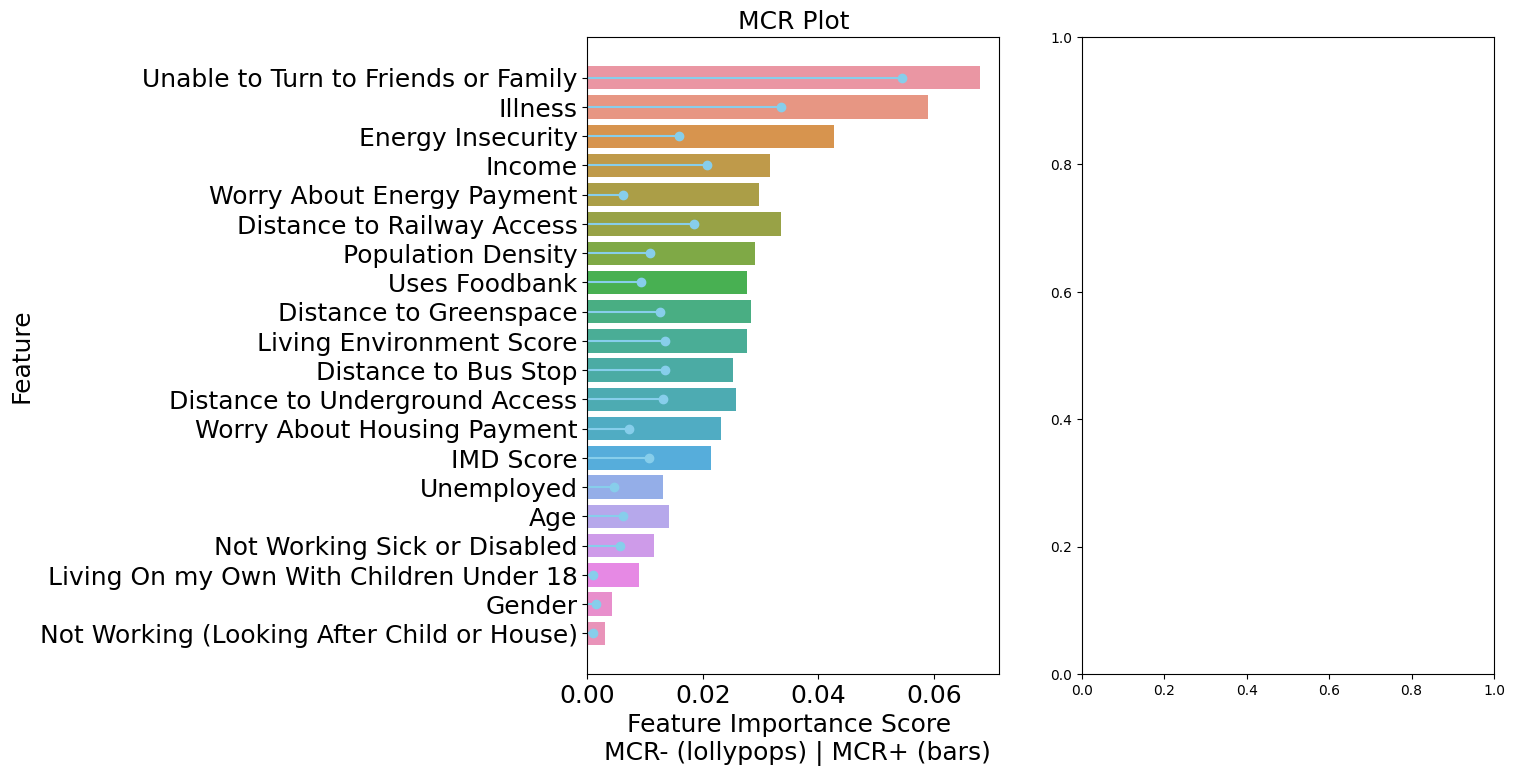

 set_estimators(self, force_use = False, var_indexs = [0], debug = True )


100%|===================| 5634/5644 [01:14<00:00]        

 set_estimators(self, force_use = False, var_indexs = [1], debug = True )


100%|===================| 5630/5644 [01:15<00:00]        

 set_estimators(self, force_use = False, var_indexs = [2], debug = True )


...

100%|===================| 5642/5644 [01:15<00:00]        

 set_estimators(self, force_use = False, var_indexs = [18], debug = True )


100%|===================| 5632/5644 [01:16<00:00]        

 set_estimators(self, force_use = False, var_indexs = [19], debug = True )


100%|===================| 5633/5644 [01:17<00:00]        

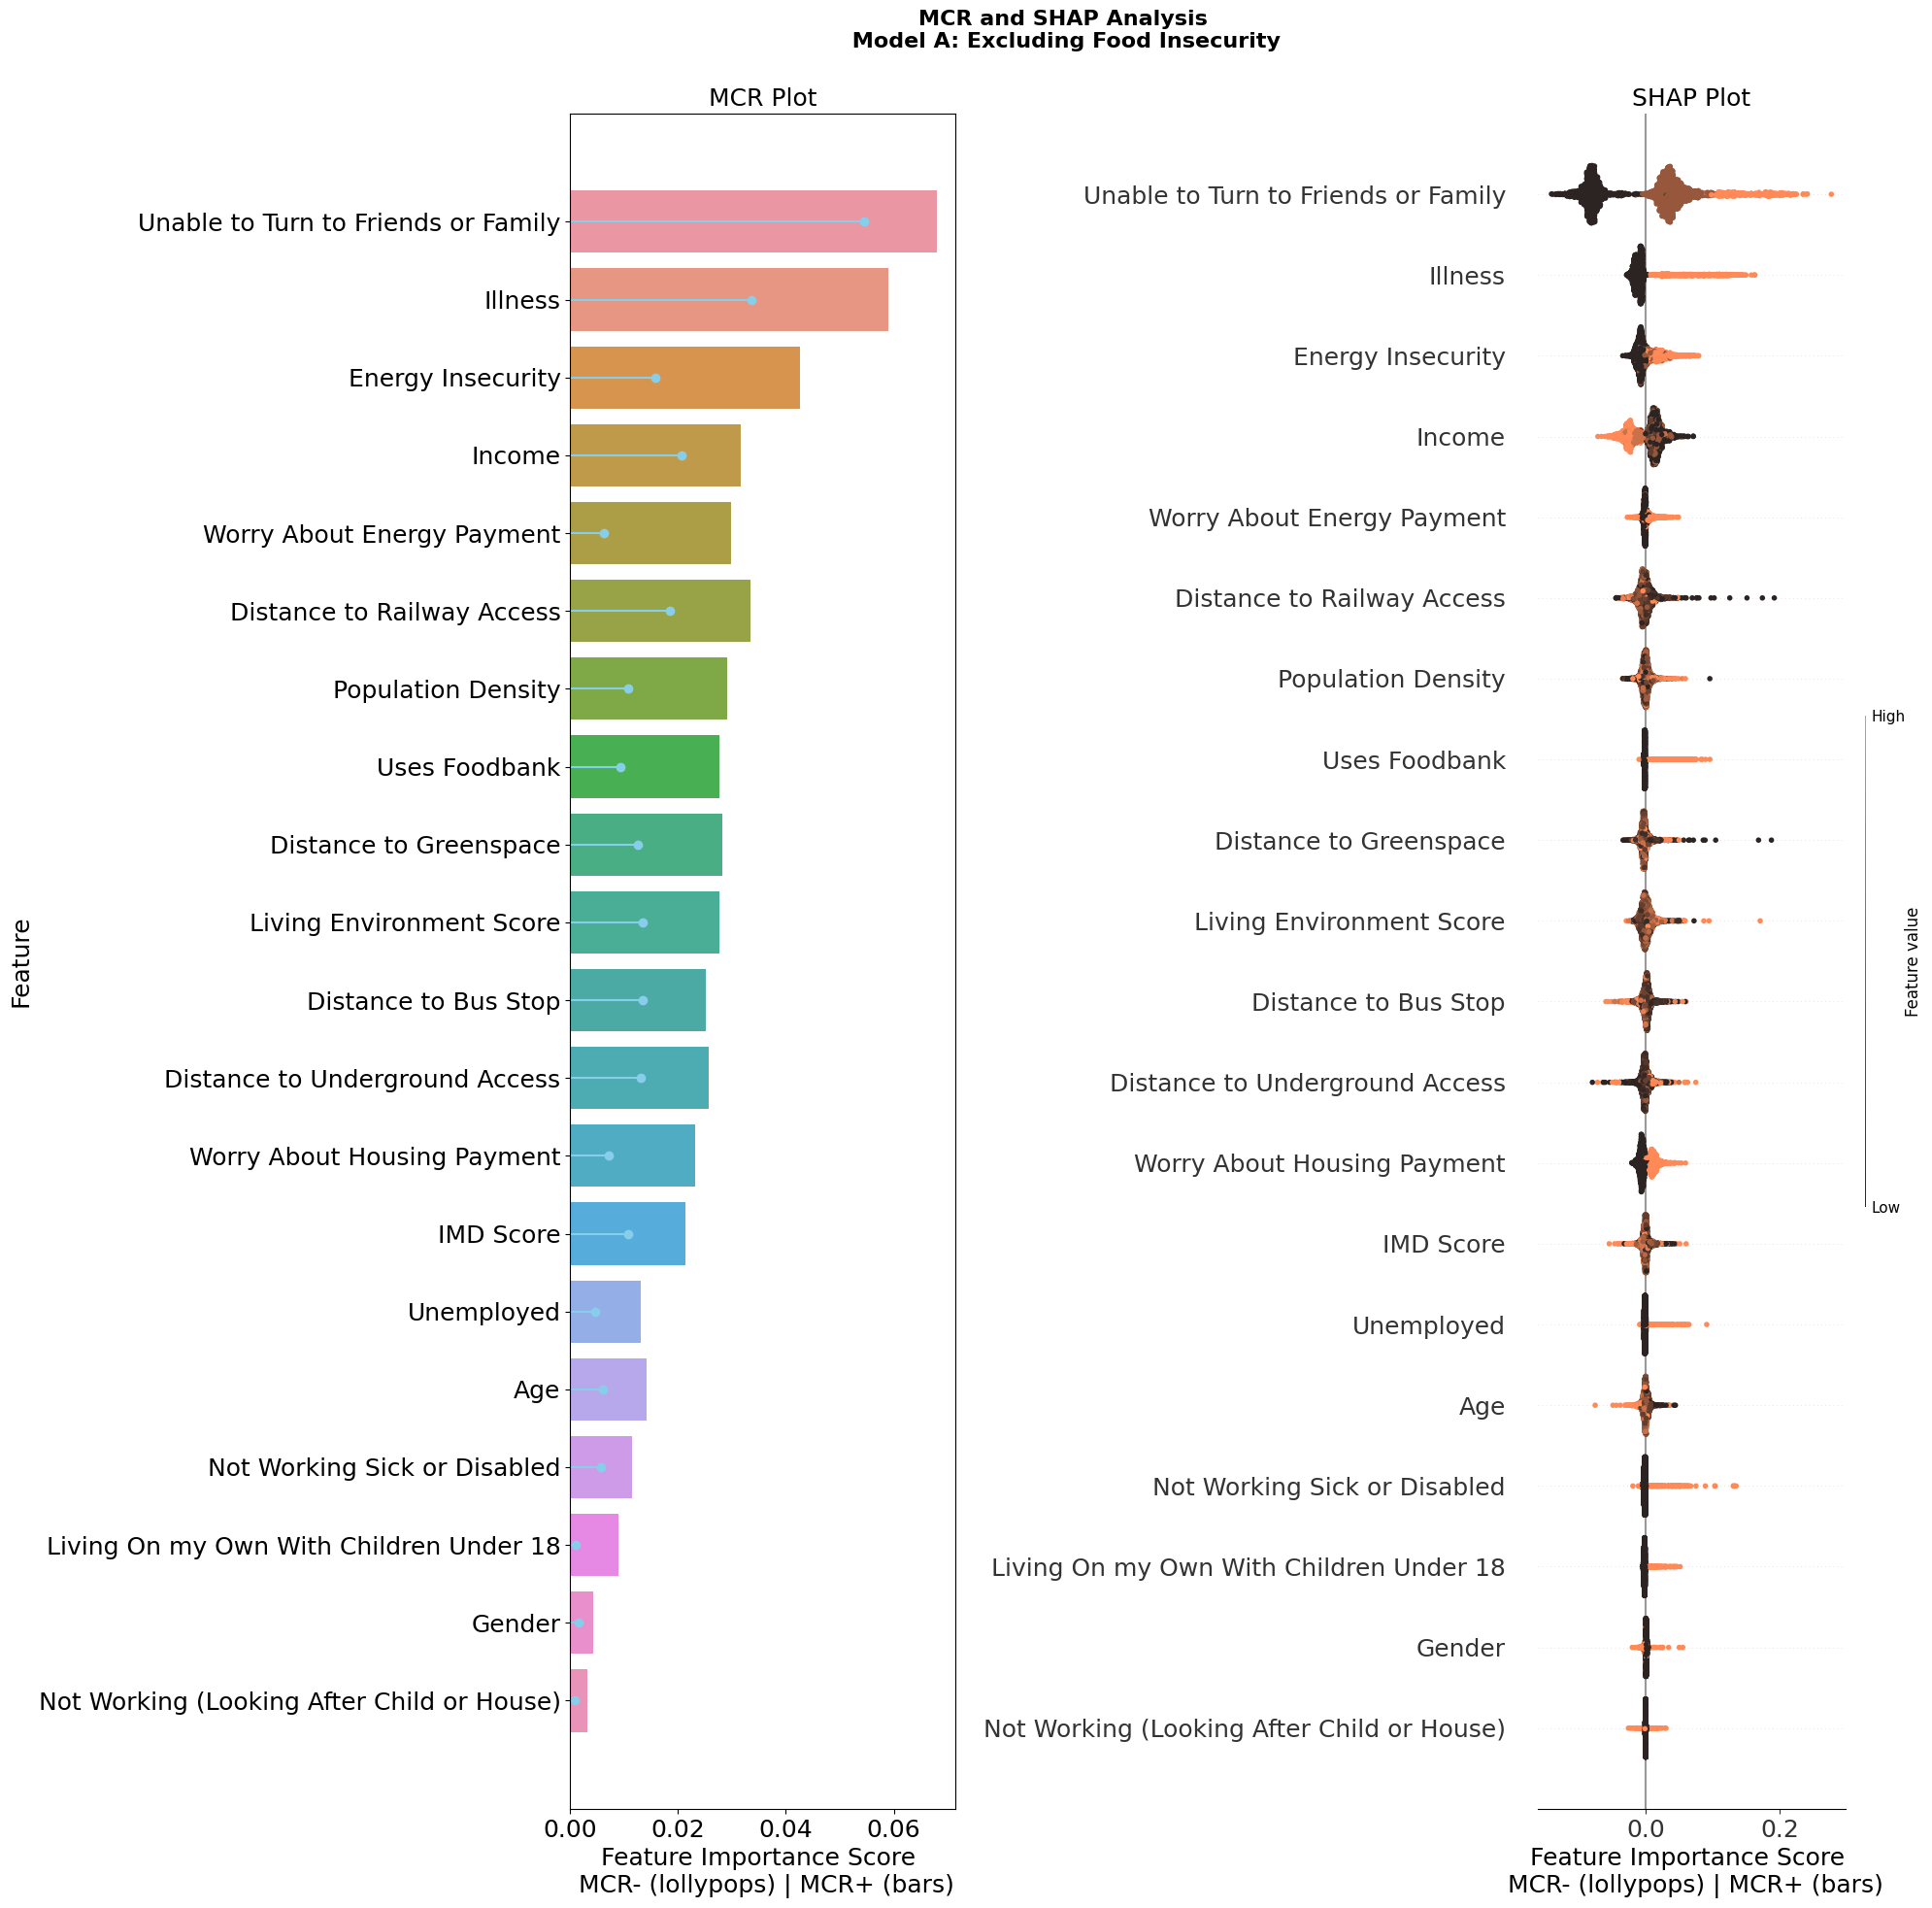

In [ ]:
X_no_food = model_df_no_food_insecurity.drop(columns=['new_loneliness_binary'])
y_no_food = model_df_no_food_insecurity['new_loneliness_binary']
# Defining the MCR model 
mcr_model = mcr_rf(bootstrap=False, criterion='entropy', max_depth=10,
                       min_samples_split=5, n_estimators=500, random_state=42)
# Fit the MCR Random Forest estimator to the training data
mcr_model.fit(X_no_food, y_no_food.values.ravel())

fig, axs = plt.subplots(1, 2, figsize=(30, 30))  # Create a 1x2 grid of subplots
 # assigning the MCR plot to the first subplot
plt.sca(axs[0])
# plot title 
axs[0].set_title('MCR Plot', fontsize=18) 
axs[0].tick_params(labelsize=18)
axs[0].set_xlabel('MCR- (lollypops) | MCR+ (bars)', fontsize=18)
axs[0].set_ylabel('Feature', fontsize=18)
mrc_rf_estimator_mcr_table= mcr_model.plot_mcr(X_no_food, y_no_food,num_times=25)
#plot_ordered_mcr_graph(mrc_rf_estimator_mcr_table, sort_by='MCR+')
# calling the function that plots the MCR, ordred by MCR+ or MCR- column in the mrc_rf_estimator_mcr_table
#plot_ordered_mcr_graph(mrc_rf_estimator_mcr_table, fig_size = (11.7, 8.27))

# assigning the MCR SHAP plot to the first subplot
plt.sca(axs[1])

mcr_shap_plot = mcr_model.mcr_shap_plot(X_no_food, variables_of_interest = None, mcr_plus = False, plot_size = (20, 20), sort = False)
axs[1].set_title('SHAP Plot', fontsize=18) 
axs[1].tick_params(labelsize=18)
axs[1].set_xlabel('Feature Importance Score \n MCR- (lollypops) | MCR+ (bars)', fontsize=18)
    #axs[1].set_title('SHAP Values ordered by MCR+') 
fig.suptitle('MCR and SHAP Analysis\n Model A: Excluding Food Insecurity\n \n ', fontsize=16, x=0.55, fontweight='bold')
# Automatically adjust subplot parameters to give specified padding

# Show the plot
axs[1].yaxis.set_visible(True)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

## Model B: Excluding Energy Insecurity

Processing MCR+ groups of features.


100%|██████████| 20/20 [01:32<00:00,  4.63s/it]


Processing MCR- groups of features.


100%|██████████| 20/20 [01:30<00:00,  4.52s/it]


MCR+ sum: 0.5199999999999996


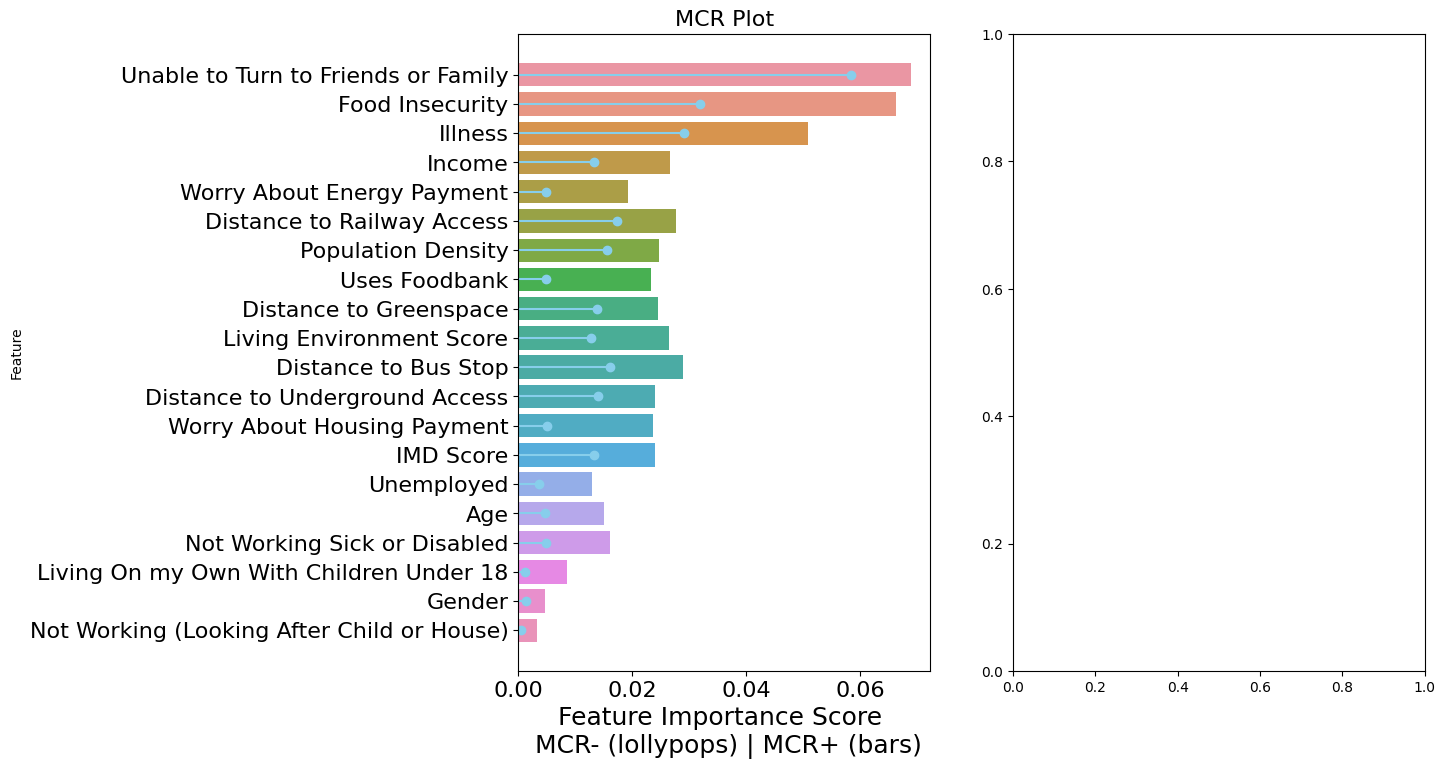

 set_estimators(self, force_use = False, var_indexs = [0], debug = True )


100%|===================| 5639/5644 [01:13<00:00]        

 set_estimators(self, force_use = False, var_indexs = [1], debug = True )


 99%|===================| 5602/5644 [01:13<00:00]        

 set_estimators(self, force_use = False, var_indexs = [2], debug = True )


...

 99%|===================| 5606/5644 [01:14<00:00]        

 set_estimators(self, force_use = False, var_indexs = [18], debug = True )


100%|===================| 5637/5644 [01:15<00:00]        

 set_estimators(self, force_use = False, var_indexs = [19], debug = True )


 99%|===================| 5608/5644 [01:21<00:00]        

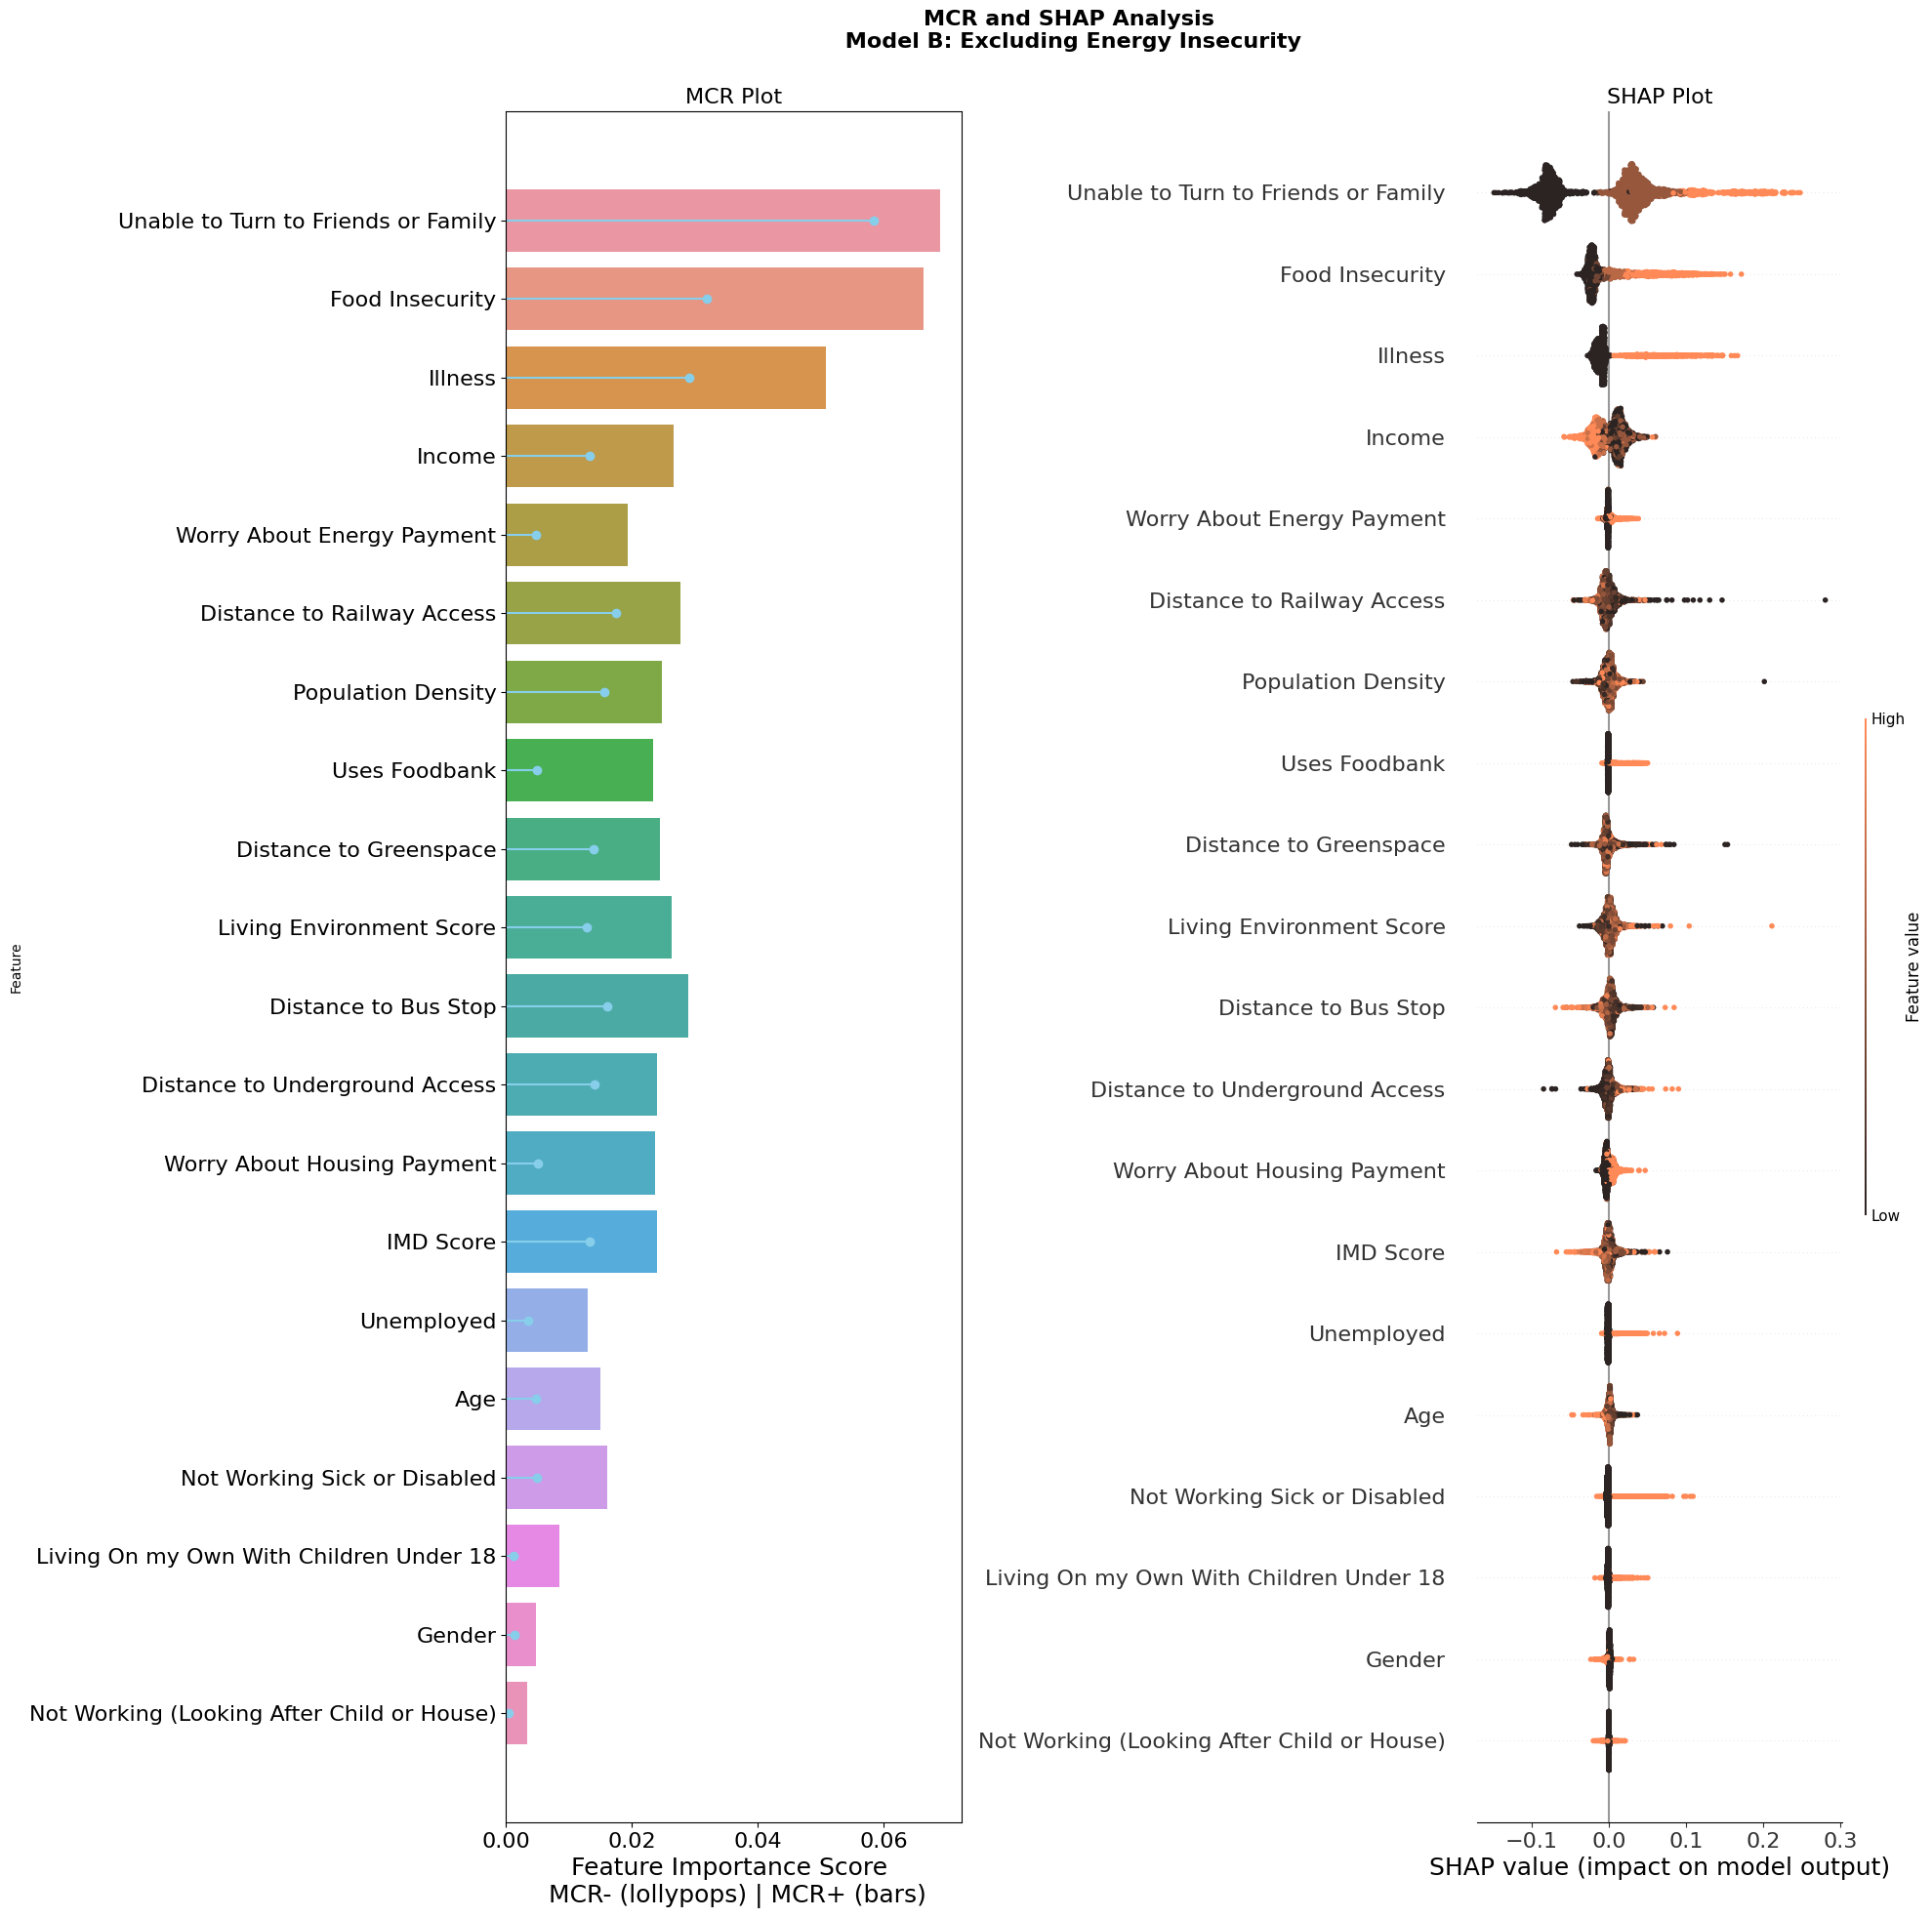

In [ ]:
X_no_energy = model_df_no_energy_insecurity.drop(columns=['new_loneliness_binary'])
y_no_energy = model_df_no_energy_insecurity['new_loneliness_binary']
# Defining the MCR model 
mcr_model = mcr_rf(ootstrap=False, criterion='entropy', max_depth=10,
                       n_estimators=500, random_state=43)
# Fit the MCR Random Forest estimator to the training data
mcr_model.fit(X_no_energy, y_no_energy.values.ravel())

fig, axs = plt.subplots(1, 2, figsize=(30, 30))  # Create a 1x2 grid of subplots
 # assigning the MCR plot to the first subplot
plt.sca(axs[0])
# plot title 
axs[0].set_title('MCR Plot', fontsize=16) 
axs[0].tick_params(labelsize=16)
axs[0].set_xlabel('Feature Importance Score \n MCR- (lollypops) | MCR+ (bars)', fontsize=18)
mrc_rf_estimator_mcr_table= mcr_model.plot_mcr(X_no_energy, y_no_energy,num_times=25)
#plot_ordered_mcr_graph(mrc_rf_estimator_mcr_table, sort_by='MCR+')
# calling the function that plots the MCR, ordred by MCR+ or MCR- column in the mrc_rf_estimator_mcr_table
#plot_ordered_mcr_graph(mrc_rf_estimator_mcr_table, fig_size = (11.7, 8.27))

# assigning the MCR SHAP plot to the first subplot
plt.sca(axs[1])

mcr_shap_plot = mcr_model.mcr_shap_plot(X_no_energy, variables_of_interest = None, mcr_plus = False, plot_size = (20, 20), sort = False)
axs[1].set_title('SHAP Plot', fontsize=16) 
axs[1].tick_params(labelsize=16)
axs[1].set_xlabel('SHAP value (impact on model output)', fontsize=18)
    #axs[1].set_title('SHAP Values ordered by MCR+') 
fig.suptitle('MCR and SHAP Analysis\n Model B: Excluding Energy Insecurity\n \n ', fontsize=16, x=0.55, fontweight='bold')
# Automatically adjust subplot parameters to give specified padding

# Show the plot
axs[1].yaxis.set_visible(True)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

## Model C: Excluding Food insecurity and Energy Insecurity

Processing MCR+ groups of features.


100%|██████████| 19/19 [01:29<00:00,  4.73s/it]


Processing MCR- groups of features.


100%|██████████| 19/19 [01:26<00:00,  4.55s/it]


MCR+ sum: 0.48591070163004946


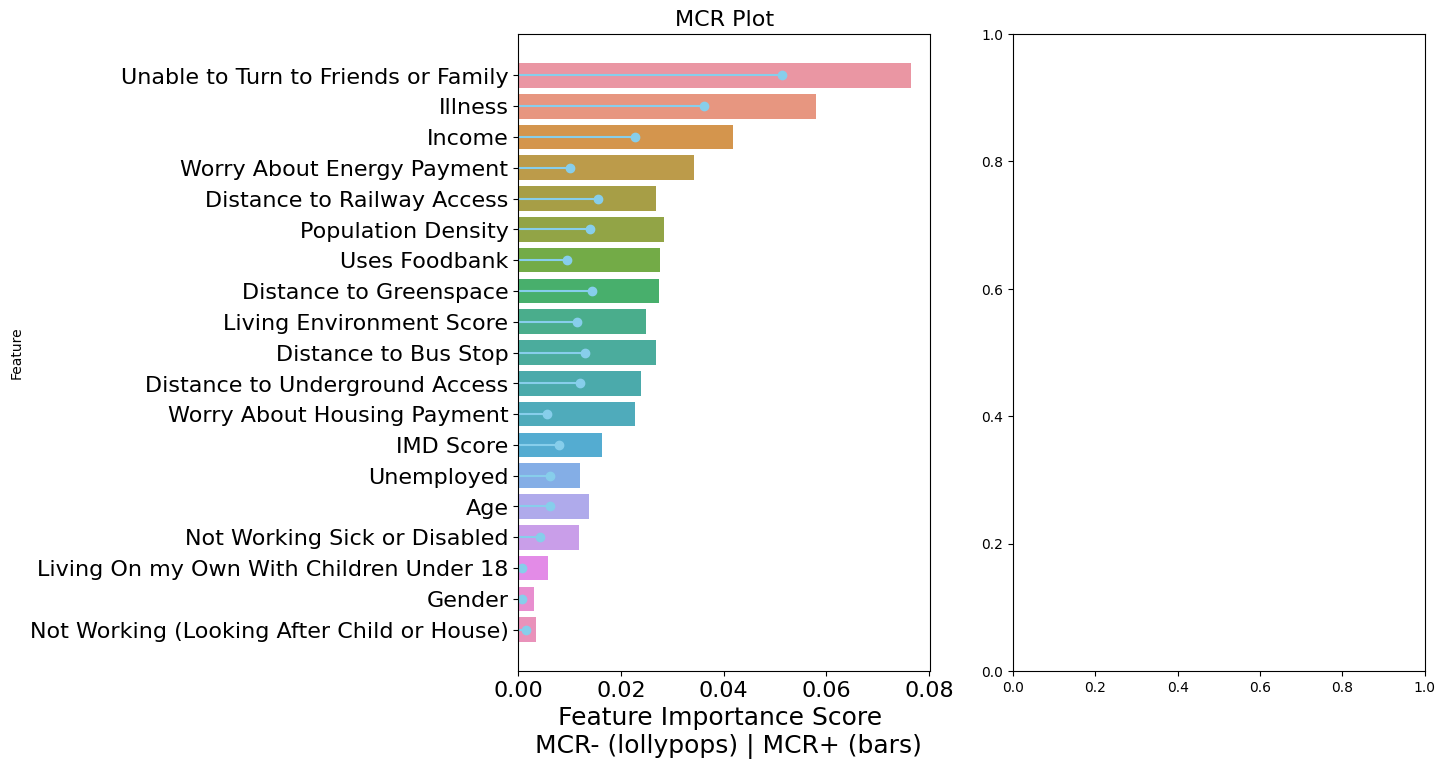

 set_estimators(self, force_use = False, var_indexs = [0], debug = True )


 99%|===================| 5587/5644 [01:13<00:00]        

 set_estimators(self, force_use = False, var_indexs = [1], debug = True )


100%|===================| 5641/5644 [01:12<00:00]        

 set_estimators(self, force_use = False, var_indexs = [2], debug = True )


...

 99%|===================| 5566/5644 [01:11<00:00]        

 set_estimators(self, force_use = False, var_indexs = [17], debug = True )


 99%|===================| 5591/5644 [01:13<00:00]        

 set_estimators(self, force_use = False, var_indexs = [18], debug = True )


 99%|===================| 5580/5644 [01:14<00:00]        

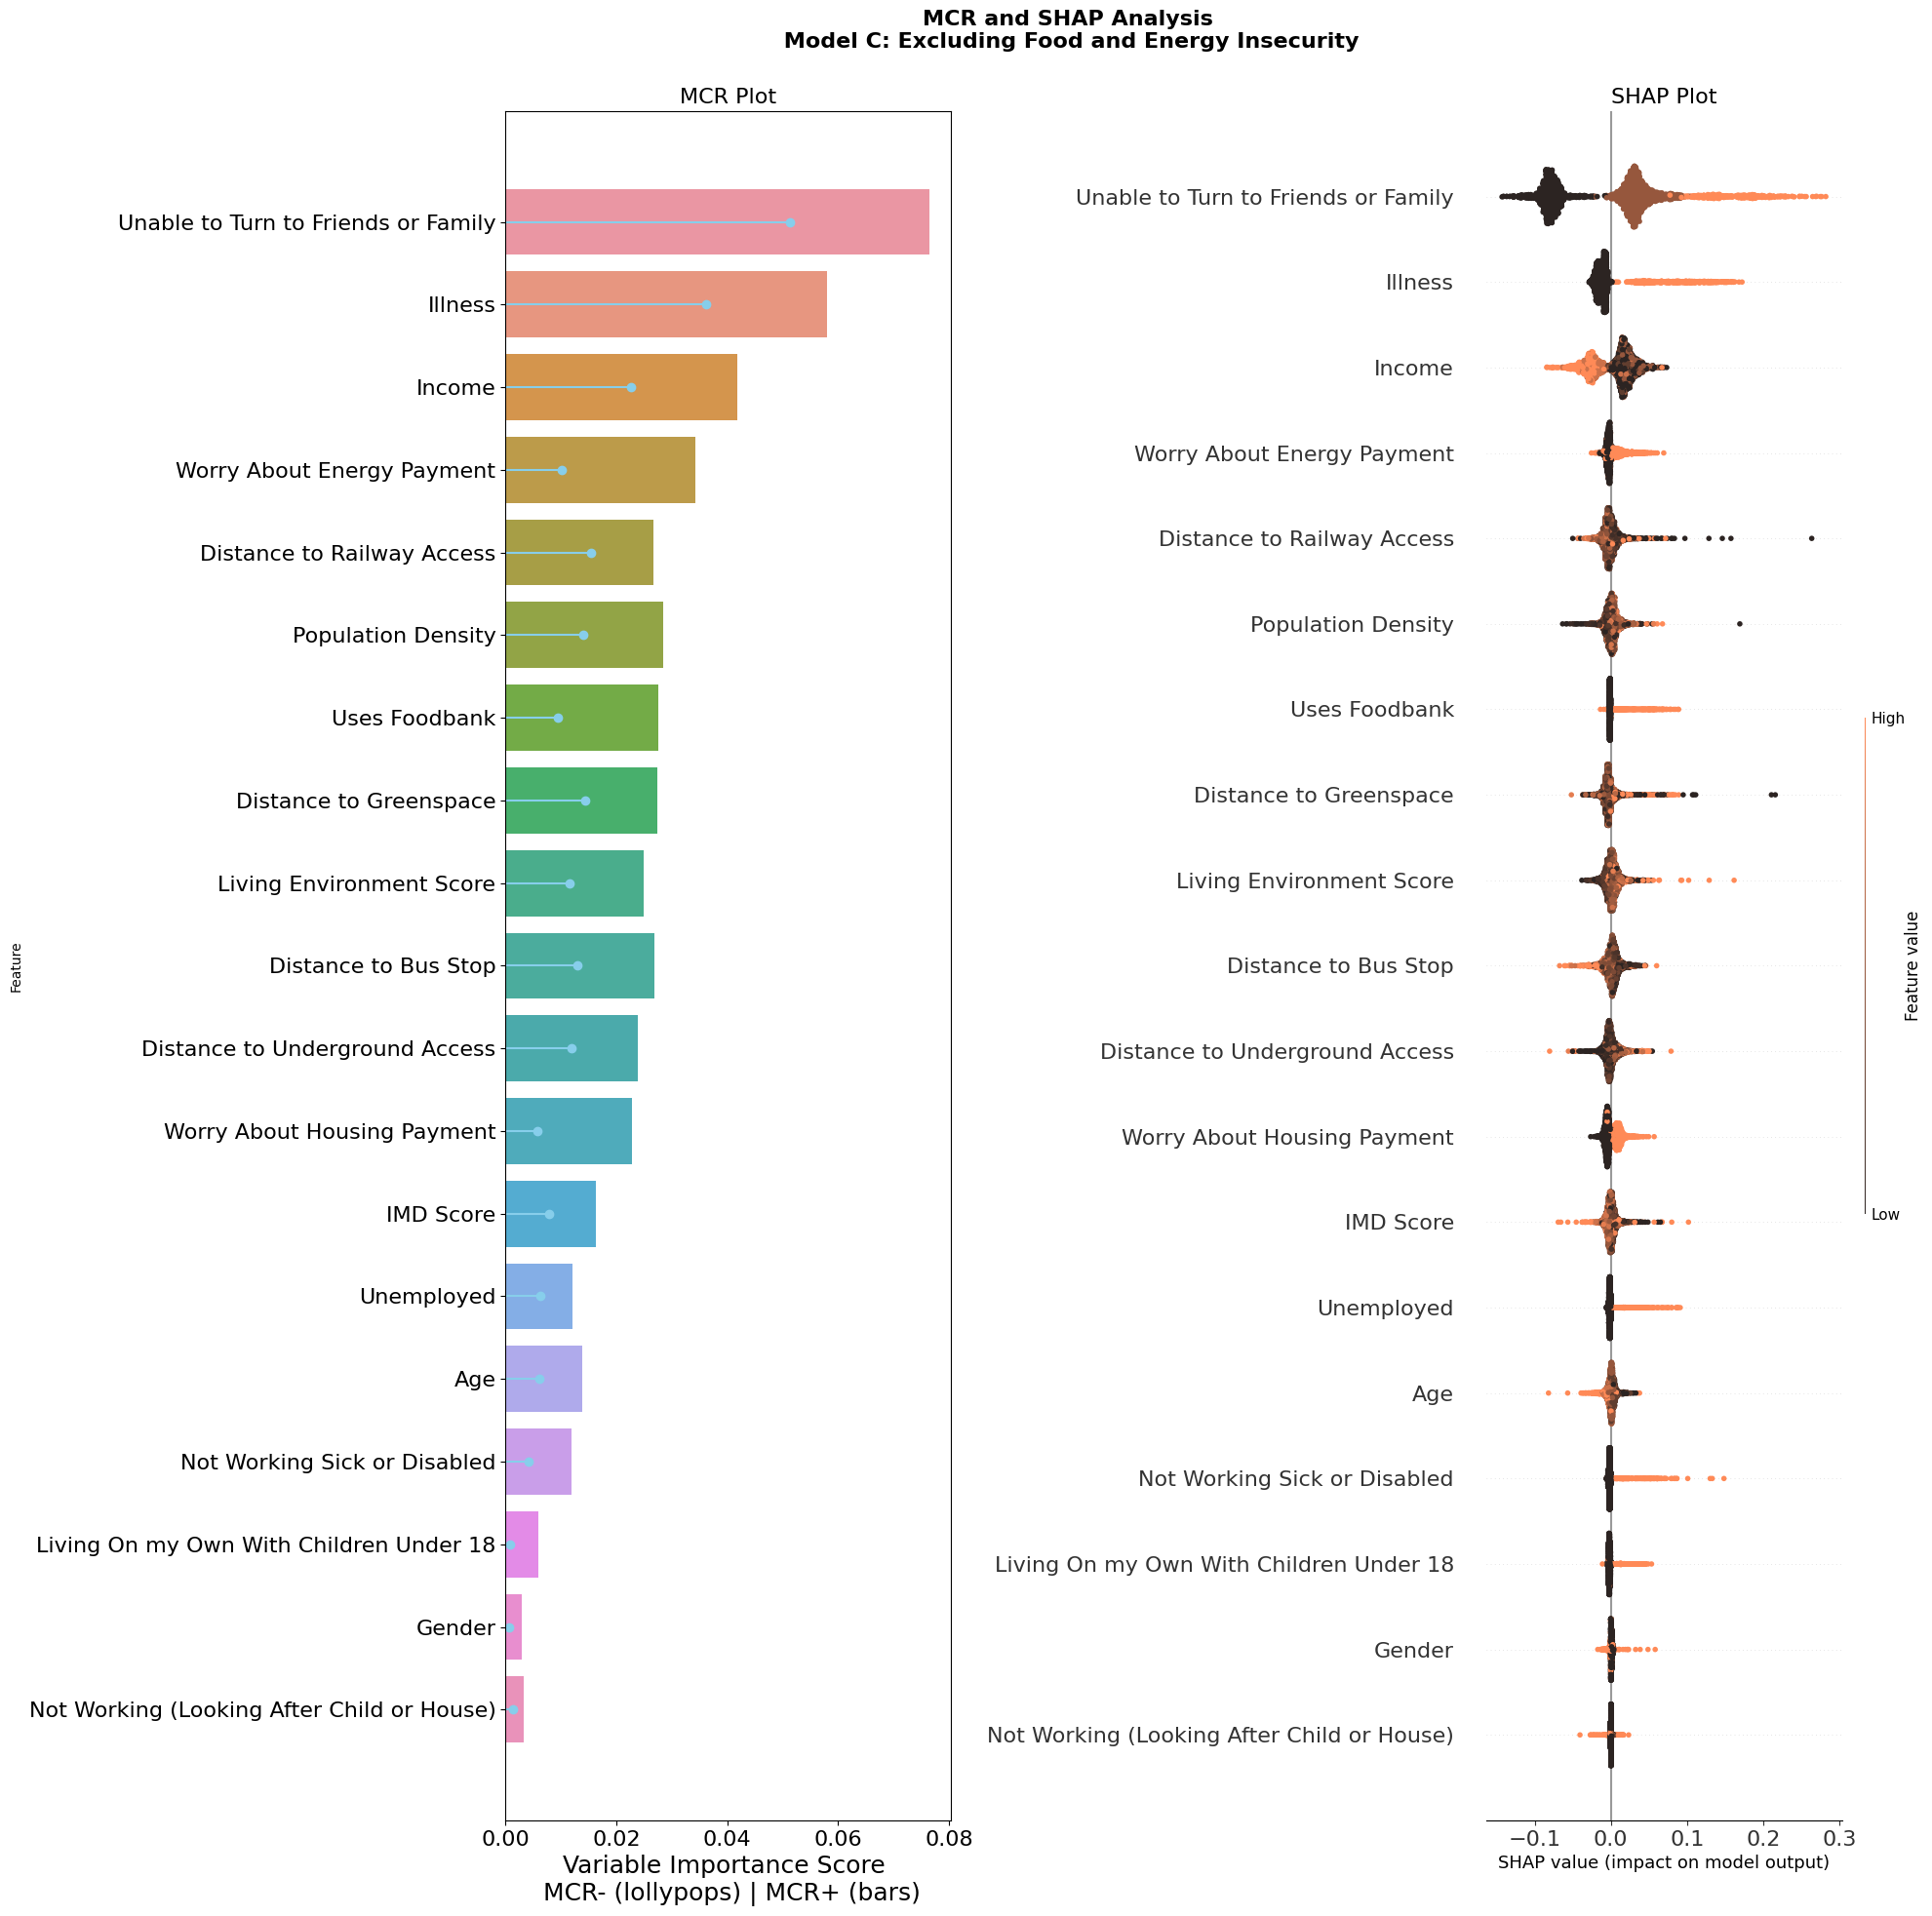

In [ ]:
# Importing the spesific dataset
X_no_food_or_energy = model_df_no_food_or_energy_insecurity.drop(columns=['new_loneliness_binary'])
y_no_food_or_energy = model_df_no_food_or_energy_insecurity['new_loneliness_binary']
# Defining the MCR model 
mcr_model = mcr_rf(bootstrap=False, criterion='entropy', max_depth=5,
                       min_samples_split=7, n_estimators=500, random_state=44)
# Fit the MCR Random Forest estimator to the training data
mcr_model.fit(X_no_food_or_energy, y_no_food_or_energy.values.ravel())

fig, axs = plt.subplots(1, 2, figsize=(30, 30))  # Create a 1x2 grid of subplots
 # assigning the MCR plot to the first subplot
plt.sca(axs[0])
# plot title 
axs[0].set_title('MCR Plot', fontsize=16) 
axs[0].tick_params(labelsize=16)
axs[0].set_xlabel('Feature Importance Score \n MCR- (lollypops) | MCR+ (bars)', fontsize=18)
mrc_rf_estimator_mcr_table= mcr_model.plot_mcr(X_no_food_or_energy, y_no_food_or_energy,num_times=25)
#plot_ordered_mcr_graph(mrc_rf_estimator_mcr_table, sort_by='MCR+')
# calling the function that plots the MCR, ordred by MCR+ or MCR- column in the mrc_rf_estimator_mcr_table
#plot_ordered_mcr_graph(mrc_rf_estimator_mcr_table, fig_size = (11.7, 8.27))

# assigning the MCR SHAP plot to the first subplot
plt.sca(axs[1])

mcr_shap_plot = mcr_model.mcr_shap_plot(X_no_food_or_energy, variables_of_interest = None, mcr_plus = False, plot_size = (20, 20), sort = False)
axs[1].set_title('SHAP Plot', fontsize=16) 
axs[1].tick_params(labelsize=16)
axs[0].set_xlabel('Variable Importance Score \n MCR- (lollypops) | MCR+ (bars)', fontsize=18)
    #axs[1].set_title('SHAP Values ordered by MCR+') 
fig.suptitle('MCR and SHAP Analysis\n Model C: Excluding Food and Energy Insecurity\n \n ', fontsize=16, x=0.55, fontweight='bold')
# Automatically adjust subplot parameters to give specified padding

# Show the plot
axs[1].yaxis.set_visible(True)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()